In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('../data/katalog_gempa.csv')
df

,tgl,ot,lat,lon,depth,mag,remark,strike1,dip1,rake1,strike2,dip2,rake2
0,2008/11/01,21:02:43.058,-9.18,119.06,10,4.9,Sumba Region - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
1,2008/11/01,20:58:50.248,-6.55,129.64,10,4.6,Banda Sea,NaN,NaN,NaN,NaN,NaN,NaN
2,2008/11/01,17:43:12.941,-7.01,106.63,121,3.7,Java - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
3,2008/11/01,16:24:14.755,-3.30,127.85,10,3.2,Seram - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
4,2008/11/01,16:20:37.327,-6.41,129.54,70,4.3,Banda Sea,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
92882,2023/01/26,02:25:09.288,3.24,127.18,10,4.0,Talaud Islands - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
92883,2023/01/26,02:15:03.893,2.70,127.10,10,3.9,Northern Molucca Sea,NaN,NaN,NaN,NaN,NaN,NaN
92884,2023/01/26,01:57:08.885,-7.83,121.07,10,3.8,Flores Sea,NaN,NaN,NaN,NaN,NaN,NaN
92885,2023/01/26,01:46:21.009,3.00,127.16,10,4.1,Northern Molucca Sea,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
cols_to_drop = ['ot', 'strike1', 'dip1', 'rake1', 'strike2', 'dip2', 'rake2']
df = df.drop(cols_to_drop, axis=1)

In [4]:
df['tgl'] = pd.to_datetime(df['tgl'])

In [5]:
print("\n=== DATA OVERVIEW ===")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
print(df.head())


=== DATA OVERVIEW ===
Shape: (92887, 6)

Columns: ['tgl', 'lat', 'lon', 'depth', 'mag', 'remark']

Missing values:
tgl       0
lat       0
lon       0
depth     0
mag       0
remark    0
dtype: int64

Data types:
tgl       datetime64[ns]
lat              float64
lon              float64
depth              int64
mag              float64
remark            object
dtype: object

First 5 rows:
         tgl   lat     lon  depth  mag                    remark
0 2008-11-01 -9.18  119.06     10  4.9  Sumba Region - Indonesia
1 2008-11-01 -6.55  129.64     10  4.6                 Banda Sea
2 2008-11-01 -7.01  106.63    121  3.7          Java - Indonesia
3 2008-11-01 -3.30  127.85     10  3.2         Seram - Indonesia
4 2008-11-01 -6.41  129.54     70  4.3                 Banda Sea


In [6]:
print("\n=== BASIC STATISTICS ===")
print(df[['lat', 'lon', 'depth', 'mag']].describe())


=== BASIC STATISTICS ===
                lat           lon         depth           mag
count  92887.000000  92887.000000  92887.000000  92887.000000
mean      -3.404577    119.159707     49.009399      3.592788
std        4.354584     10.833202     76.761070      0.834042
min      -11.000000     94.020000      2.000000      1.000000
25%       -7.885000    113.170000     10.000000      3.000000
50%       -2.910000    121.160000     16.000000      3.500000
75%        0.140000    126.900000     54.000000      4.200000
max        6.000000    142.000000    750.000000      7.900000


In [7]:
# ========================
# 1. PREPARASI DATA CLUSTERING
# ========================
print("\n=== PREPARASI DATA UNTUK CLUSTERING ===")

# Pilih fitur untuk clustering (latitude, longitude, magnitude, depth)
features = ['lat', 'lon', 'mag', 'depth']
X = df[features].values

# Standarisasi data (penting untuk DBSCAN)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



=== PREPARASI DATA UNTUK CLUSTERING ===



=== ANALISIS UNTUK MENENTUKAN PARAMETER DBSCAN ===


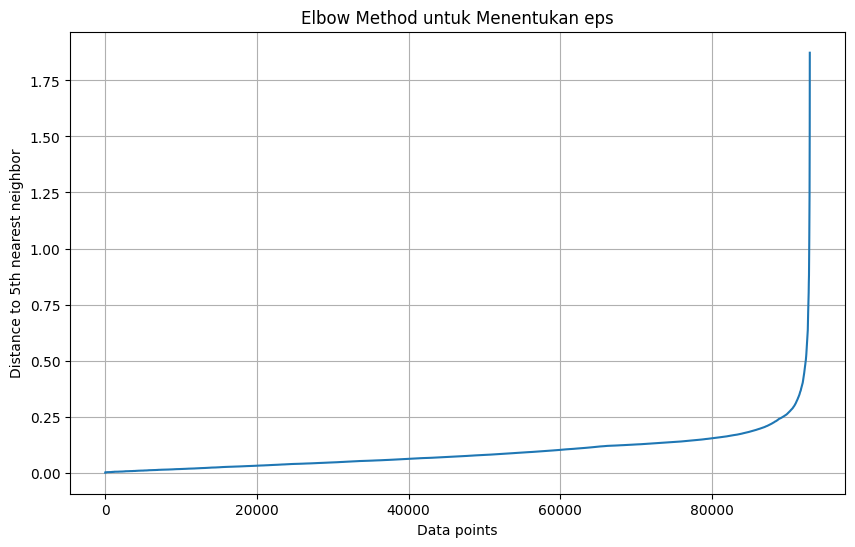


=== REKOMENDASI PARAMETER ===
Berdasarkan plot elbow, pertimbangkan eps antara 0.3-0.5
Untuk dataset besar (~93k data), gunakan min_samples yang lebih besar


In [8]:
# ========================
# 2. MENENTUKAN EPS DAN MIN_SAMPLES
# ========================
print("\n=== ANALISIS UNTUK MENENTUKAN PARAMETER DBSCAN ===")

from sklearn.neighbors import NearestNeighbors
import numpy as np

# Metode elbow untuk menentukan eps
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Urutkan jarak
distances = np.sort(distances[:, 4], axis=0)

# Plot elbow method
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('Elbow Method untuk Menentukan eps')
plt.xlabel('Data points')
plt.ylabel('Distance to 5th nearest neighbor')
plt.grid(True)
plt.show()

# Rekomendasi parameter berdasarkan analisis visual
print("\n=== REKOMENDASI PARAMETER ===")
print("Berdasarkan plot elbow, pertimbangkan eps antara 0.3-0.5")
print("Untuk dataset besar (~93k data), gunakan min_samples yang lebih besar")

In [9]:
# ========================
# 3. IMPLEMENTASI DBSCAN
# ========================
print("\n=== IMPLEMENTASI ALGORITMA DBSCAN ===")

from sklearn.cluster import DBSCAN

# Gunakan parameter yang direkomendasikan
eps = 0.4
min_samples = 50

# Jalankan DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
clusters = dbscan.fit_predict(X_scaled)

# Tambahkan hasil clustering ke dataframe
df['cluster'] = clusters

# ========================
# 4. ANALISIS HASIL CLUSTERING
# ========================
print("\n=== ANALISIS HASIL CLUSTERING ===")

# Hitung jumlah cluster dan noise
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

print(f"Jumlah cluster yang terbentuk: {n_clusters}")
print(f"Jumlah data noise (klaster -1): {n_noise}")
print(f"Persentase noise: {(n_noise/len(clusters))*100:.2f}%")

# Analisis persebaran data per klaster
print("\nDistribusi data per klaster:")
print(df['cluster'].value_counts().sort_index())

# Statistik per klaster
print("\n=== STATISTIK PER KLASTER ===")
for cluster_id in range(-1, n_clusters):
    cluster_data = df[df['cluster'] == cluster_id]
    if len(cluster_data) > 0:
        print(f"\nKlaster {cluster_id}: {len(cluster_data)} data")
        print(f"  Magnitude rata-rata: {cluster_data['mag'].mean():.2f}")
        print(f"  Kedalaman rata-rata: {cluster_data['depth'].mean():.2f} km")
        print(f"  Rentang latitude: {cluster_data['lat'].min():.2f} hingga {cluster_data['lat'].max():.2f}")
        print(f"  Rentang longitude: {cluster_data['lon'].min():.2f} hingga {cluster_data['lon'].max():.2f}")


=== IMPLEMENTASI ALGORITMA DBSCAN ===

=== ANALISIS HASIL CLUSTERING ===
Jumlah cluster yang terbentuk: 4
Jumlah data noise (klaster -1): 3096
Persentase noise: 3.33%

Distribusi data per klaster:
cluster
-1     3096
 0    89348
 1      159
 2      192
 3       92
Name: count, dtype: int64

=== STATISTIK PER KLASTER ===

Klaster -1: 3096 data
  Magnitude rata-rata: 4.58
  Kedalaman rata-rata: 235.47 km
  Rentang latitude: -10.98 hingga 6.00
  Rentang longitude: 94.13 hingga 141.99

Klaster 0: 89348 data
  Magnitude rata-rata: 3.56
  Kedalaman rata-rata: 40.94 km
  Rentang latitude: -11.00 hingga 6.00
  Rentang longitude: 94.02 hingga 142.00

Klaster 1: 159 data
  Magnitude rata-rata: 4.42
  Kedalaman rata-rata: 528.71 km
  Rentang latitude: -7.73 hingga -5.30
  Rentang longitude: 119.80 hingga 126.80

Klaster 2: 192 data
  Magnitude rata-rata: 3.78
  Kedalaman rata-rata: 165.01 km
  Rentang latitude: -4.78 hingga -0.66
  Rentang longitude: 99.87 hingga 104.68

Klaster 3: 92 data
  Mag


=== VISUALISASI HASIL CLUSTERING ===


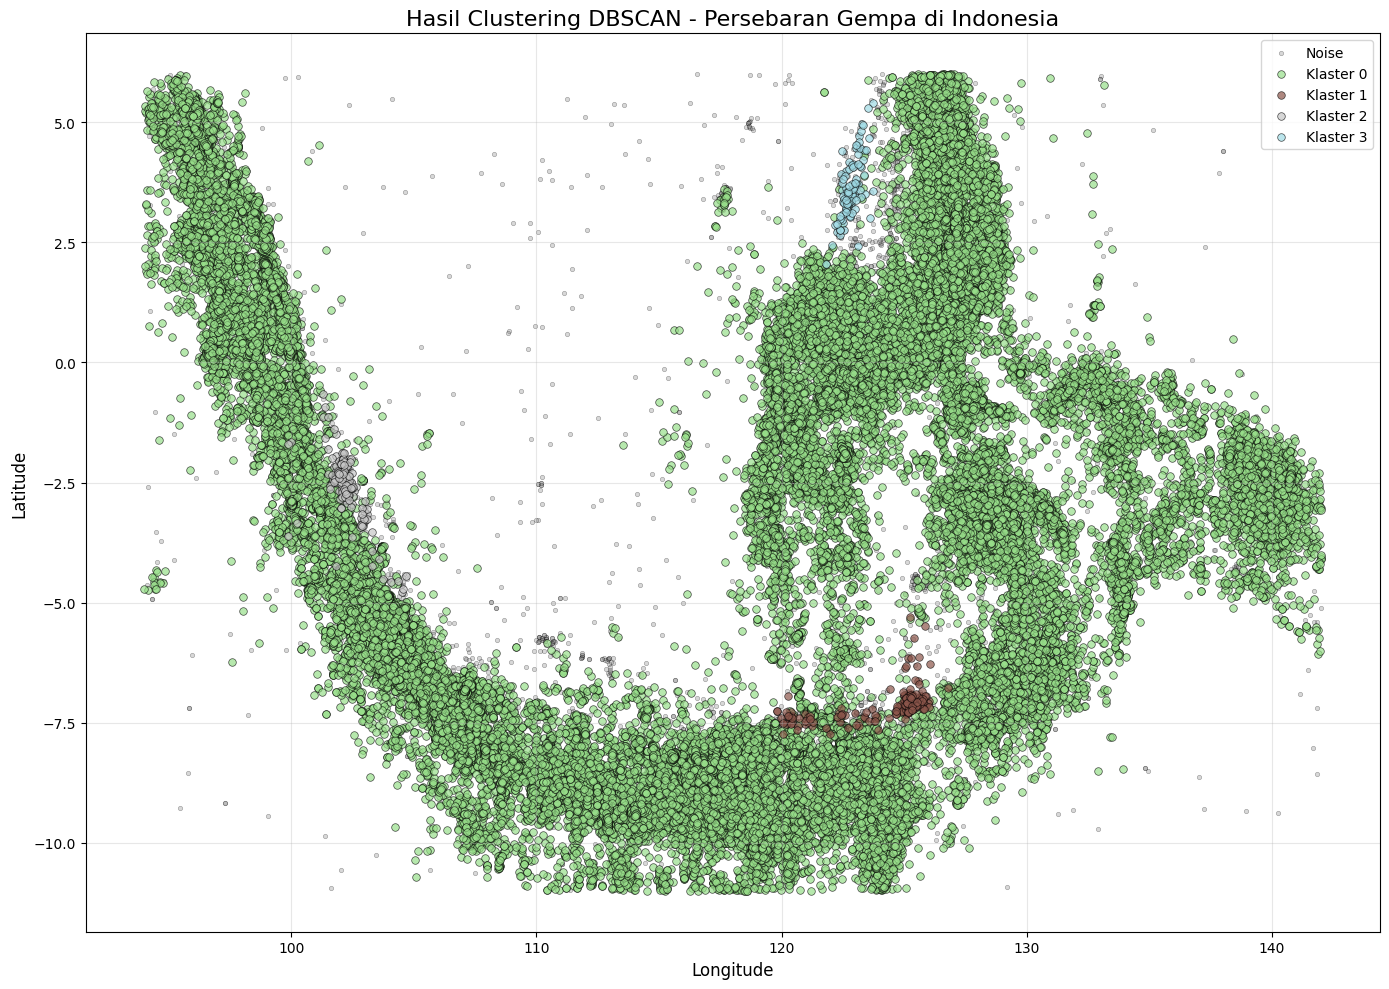

In [10]:
# ========================
# 5. VISUALISASI HASIL CLUSTERING
# ========================
print("\n=== VISUALISASI HASIL CLUSTERING ===")

# Visualisasi 1: Scatter plot berdasarkan latitude-longitude
plt.figure(figsize=(14, 10))

# Buat color map untuk klaster
unique_clusters = sorted(df['cluster'].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))

for cluster_id, color in zip(unique_clusters, colors):
    if cluster_id == -1:
        color = 'gray'  # Noise berwarna abu-abu
        alpha = 0.3
        label = 'Noise'
        size = 10
    else:
        alpha = 0.7
        label = f'Klaster {cluster_id}'
        size = 30
    
    cluster_data = df[df['cluster'] == cluster_id]
    plt.scatter(cluster_data['lon'], cluster_data['lat'], 
                c=[color], alpha=alpha, label=label, s=size, edgecolors='black', linewidth=0.5)

plt.title('Hasil Clustering DBSCAN - Persebaran Gempa di Indonesia', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

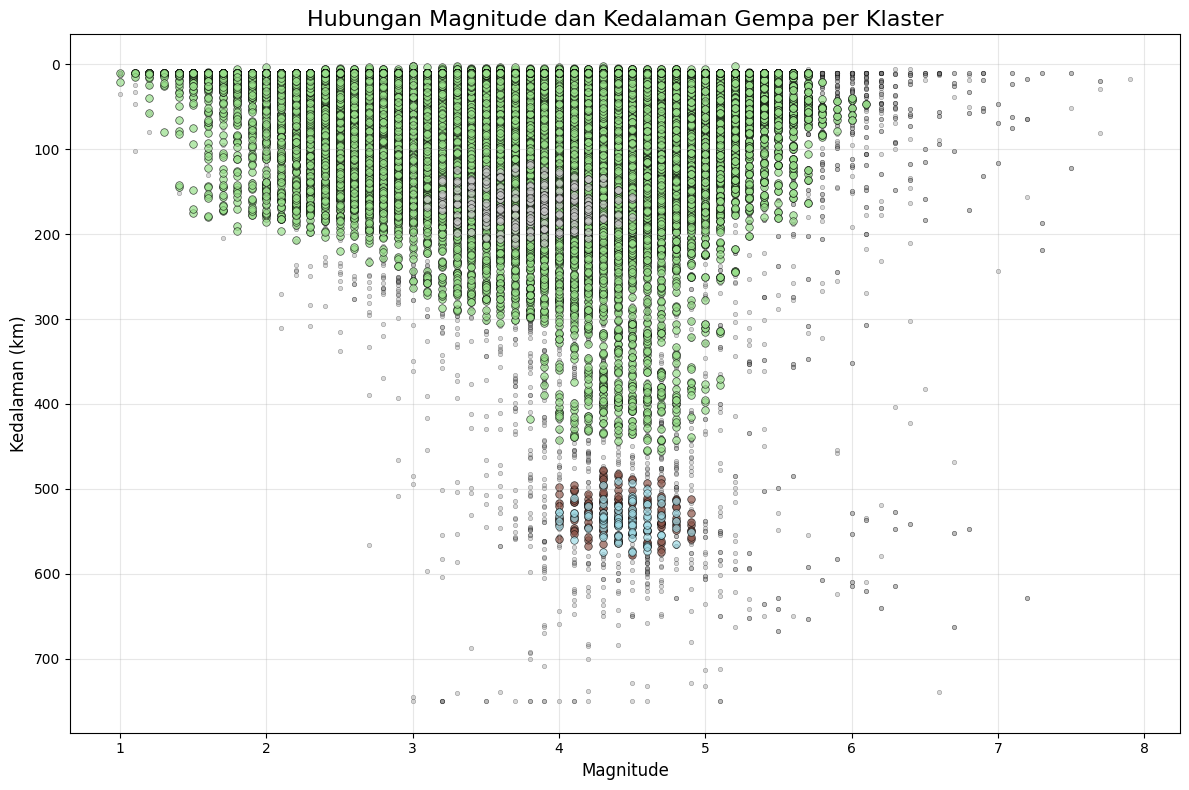

In [11]:
# Visualisasi 2: Magnitude vs Depth per klaster
plt.figure(figsize=(12, 8))

for cluster_id, color in zip(unique_clusters, colors):
    if cluster_id == -1:
        color = 'gray'
        alpha = 0.3
        size = 10
    else:
        alpha = 0.7
        size = 30
    
    cluster_data = df[df['cluster'] == cluster_id]
    plt.scatter(cluster_data['mag'], cluster_data['depth'], 
                c=[color], alpha=alpha, s=size, edgecolors='black', linewidth=0.5)

plt.title('Hubungan Magnitude dan Kedalaman Gempa per Klaster', fontsize=16)
plt.xlabel('Magnitude', fontsize=12)
plt.ylabel('Kedalaman (km)', fontsize=12)
plt.gca().invert_yaxis()  # Invert agar kedalaman semakin dalam semakin ke bawah
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


=== VISUALISASI PETA GPS INDONESIA ===


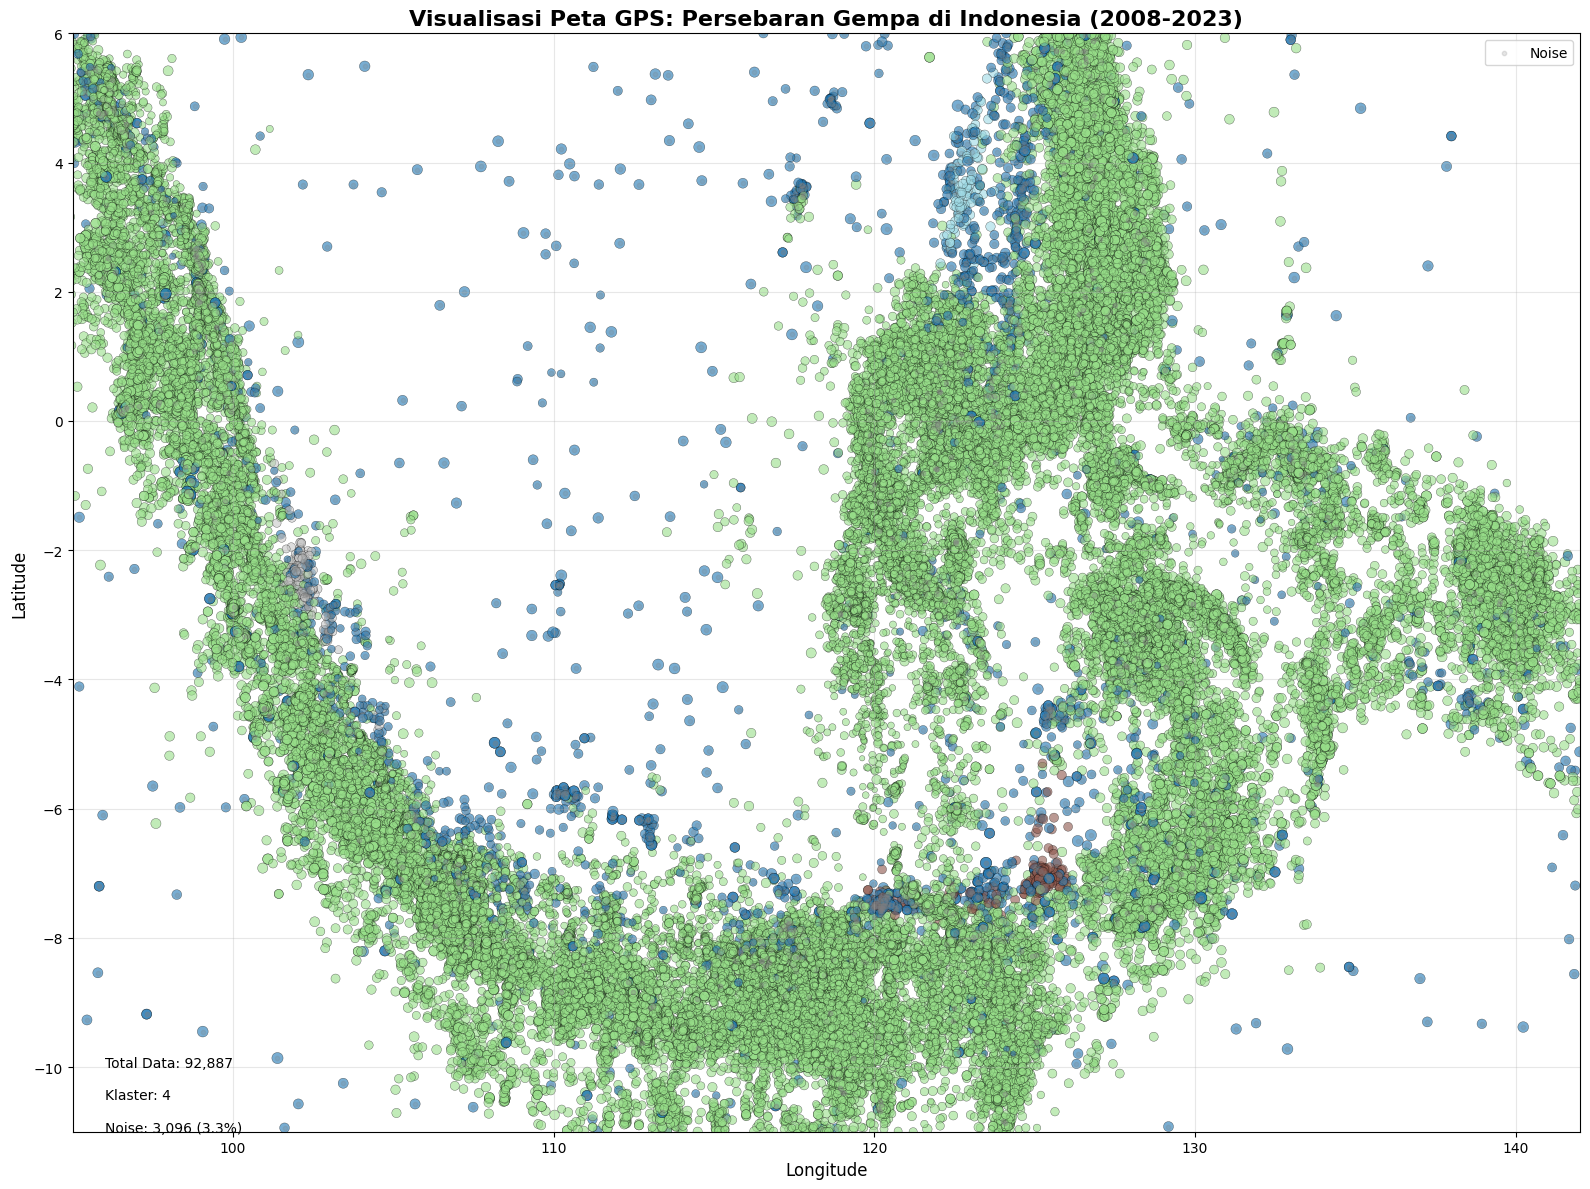

In [12]:
# ========================
# 6. VISUALISASI PETA GPS
# ========================
print("\n=== VISUALISASI PETA GPS INDONESIA ===")

plt.figure(figsize=(16, 12))

# Plot peta Indonesia dengan lat/lon
plt.scatter(df['lon'], df['lat'], 
           c=df['cluster'], cmap='tab20', 
           s=df['mag']*10,  # Ukuran titik berdasarkan magnitude
           alpha=0.6, 
           edgecolors='black', 
           linewidth=0.3)

# Tambahkan warna berbeda untuk noise
noise_data = df[df['cluster'] == -1]
if len(noise_data) > 0:
    plt.scatter(noise_data['lon'], noise_data['lat'], 
               c='gray', alpha=0.2, s=10, label='Noise')

plt.title('Visualisasi Peta GPS: Persebaran Gempa di Indonesia (2008-2023)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Tambahkan grid dan batas peta Indonesia
plt.xlim(95, 142)
plt.ylim(-11, 6)
plt.grid(True, alpha=0.3)

# Tambahkan informasi tambahan
plt.text(96, -10, f'Total Data: {len(df):,}', fontsize=10)
plt.text(96, -10.5, f'Klaster: {n_clusters}', fontsize=10)
plt.text(96, -11, f'Noise: {n_noise:,} ({n_noise/len(df)*100:.1f}%)', fontsize=10)

plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()


=== ANALISIS TAMBAHAN ===


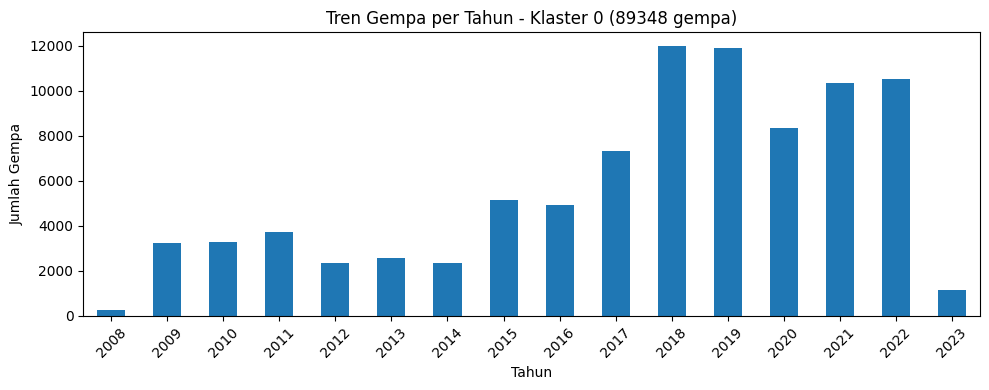

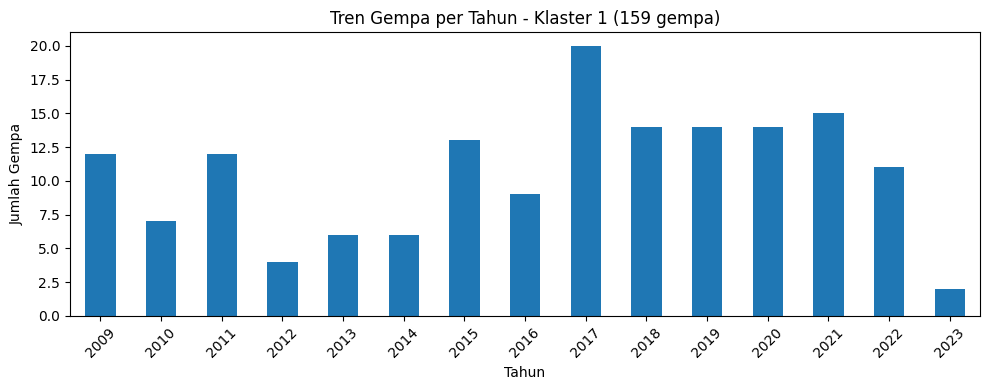

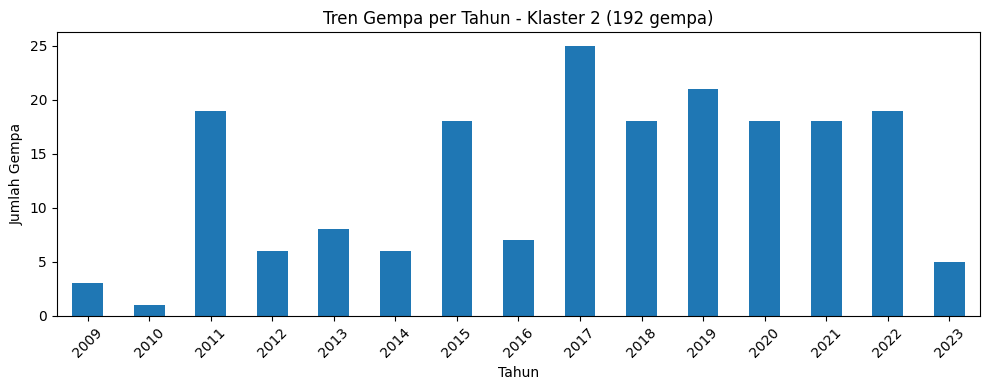

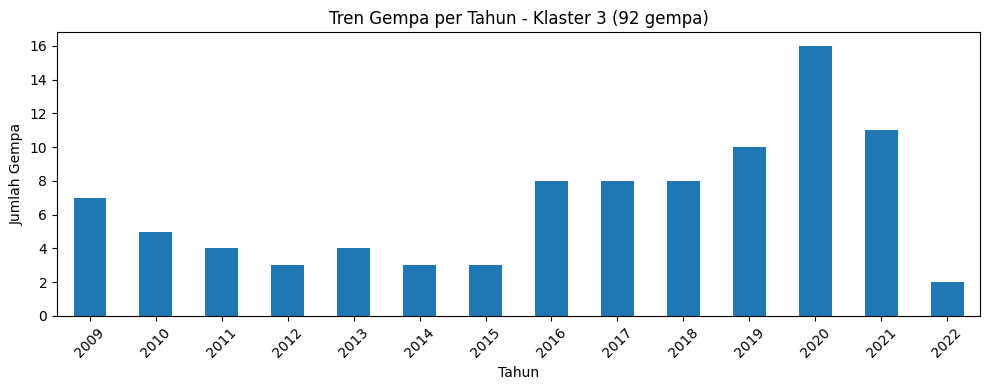


=== KESIMPULAN ===
1. DBSCAN berhasil mengelompokkan gempa berdasarkan lokasi geografis
2. Parameter yang digunakan: eps=0.4, min_samples=50
3. Hasil menunjukkan pola persebaran gempa di berbagai wilayah Indonesia
4. Data noise menunjukkan gempa-gempa yang terisolasi
5. Visualisasi membantu identifikasi zona seismik aktif


In [13]:
# ========================
# 7. ANALISIS TAMBAHAN
# ========================
print("\n=== ANALISIS TAMBAHAN ===")

# Frekuensi gempa per tahun per klaster utama
df['year'] = df['tgl'].dt.year
for cluster_id in range(n_clusters):
    if cluster_id < 5:  # Analisis untuk 5 klaster utama saja
        cluster_data = df[df['cluster'] == cluster_id]
        yearly_counts = cluster_data['year'].value_counts().sort_index()
        
        plt.figure(figsize=(10, 4))
        yearly_counts.plot(kind='bar')
        plt.title(f'Tren Gempa per Tahun - Klaster {cluster_id} ({len(cluster_data)} gempa)')
        plt.xlabel('Tahun')
        plt.ylabel('Jumlah Gempa')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

print("\n=== KESIMPULAN ===")
print("1. DBSCAN berhasil mengelompokkan gempa berdasarkan lokasi geografis")
print("2. Parameter yang digunakan: eps=0.4, min_samples=50")
print("3. Hasil menunjukkan pola persebaran gempa di berbagai wilayah Indonesia")
print("4. Data noise menunjukkan gempa-gempa yang terisolasi")
print("5. Visualisasi membantu identifikasi zona seismik aktif")